# 03 - Auditoria de reduccion negativa

Este notebook audita los datasets reducidos usados para modelado. No entrena modelos. Revisa dimensiones, representatividad de colores y que el holdout quede completo.


## Lectura operativa

- `train`: WR de entrenamiento y negativas reducidas.
- `threshold_calibration`: negativas restantes del train original para elegir umbral.
- `holdout`: test final separado antes de reducir negativas; conserva el desbalance natural.
- SMOTE/SMOTEENN no se aplica aqui. Ocurre despues dentro del pipeline de modelado.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force an interactive notebook backend when running cells manually.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass
from IPython.display import Markdown, Image, display

try:
    import seaborn as sns
except ImportError:
    sns = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

PALETTE = {
    "xgboost": "#2F6F9F",
    "random_forest": "#3A9D5D",
    "hist_gradient_boosting": "#B7791F",
    "logistic_regression": "#7B61A8",
    "wr": "#A8324A",
    "candidate": "#2F6F9F",
    "negative": "#6B7280",
    "muted": "#6B7280",
}

def require_path(path):
    path = Path(path)
    if not path.is_absolute():
        path = ROOT / path
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def pct(value):
    return "-" if pd.isna(value) else f"{100 * float(value):.1f}%"

def model_display(row):
    variant = str(row.get("dataset_variant", ""))
    family = "Relaxed" if variant.startswith("relaxed") else "Strict"
    dataset = variant.replace("relaxed_", "").replace("strict_", "")
    dataset = dataset.replace("photometry", "Phot").replace("parallax_soft", "Parallax+").replace("poe_", "POE>=")
    feat = "+err" if str(row.get("feature_set", "")).endswith("error") else "base"
    model = {"xgboost": "XGB", "random_forest": "RF", "hist_gradient_boosting": "HGB", "logistic_regression": "LogReg"}.get(str(row.get("model", "")), str(row.get("model", "")))
    sampler = {"smote": "SMOTE", "smote_enn": "SMOTE-ENN", "none": "sin sampler"}.get(str(row.get("sampler", "")), str(row.get("sampler", "")))
    return f"{model} {sampler} | {family} {dataset} | {feat}"

def add_model_columns(df):
    out = df.copy()
    out["model_label"] = out.apply(model_display, axis=1)
    for k in [50, 100, 500, 1000]:
        c = f"holdout_wr_at_{k}"
        if c in out.columns:
            out[f"{c}_pct"] = out[c] / out["wr_holdout"].replace(0, np.nan)
    return out

def rank_models(df, k=100):
    return df.sort_values(
        [f"holdout_wr_at_{k}_pct", "holdout_average_precision", "holdout_recall_at_100", "holdout_f2_wr"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

from wr_detector.config import load_yaml

config = load_yaml(ROOT / "configs/models.yaml")
modeling_dir = require_path(config["outputs"]["modeling_data_dir"])
summary = pd.read_csv(require_path(config["outputs"]["reduction_summary"]))
audit = pd.read_csv(require_path(config["outputs"]["reduction_audit"]))
pool_path = ROOT / config["outputs"].get("negative_pool_audit", "reports/tables/negative_pool_audit.csv")
pool_audit = pd.read_csv(pool_path) if pool_path.exists() else pd.DataFrame()


## Dimensiones por variante


non_wr                                rows  \
split                 holdout threshold_calibration train holdout   
dataset_variant                                                     
relaxed_parallax_soft    5986                 21813  2250    6045   
relaxed_photometry       6634                 24089  2620    6703   
relaxed_poe_2            4291                 15388  1810    4337   
relaxed_poe_3            4224                 15450  1670    4265   
strict_parallax_soft     5137                 18856  1940    5191   
strict_photometry        6132                 22474  2300    6194   
strict_poe_2             4039                 14824  1500    4081   
strict_poe_3             4160                 15460  1360    4197   

                                                       wr  \
split                 threshold_calibration train holdout   
dataset_variant                                             
relaxed_parallax_soft                 21813  2475      59   
relaxed_photometry                    24089  2882      69   
relaxed_poe_2                         15388  1991      46   
relaxed_poe_3                         15450  1837      41   
strict_parallax_soft                  18856  2134      54   
strict_photometry                     22474  2530      62   
strict_poe_2                          14824  1650      42   
strict_poe_3                          15460  1496      37   

                                                   
split                 threshold_calibration train  
dataset_variant                                    
relaxed_parallax_soft                     0   225  
relaxed_photometry                        0   262  
relaxed_poe_2                             0   181  
relaxed_poe_3                             0   167  
strict_parallax_soft                      0   194  
strict_photometry                         0   230  
strict_poe_2                              0   150  
strict_poe_3                              0   136

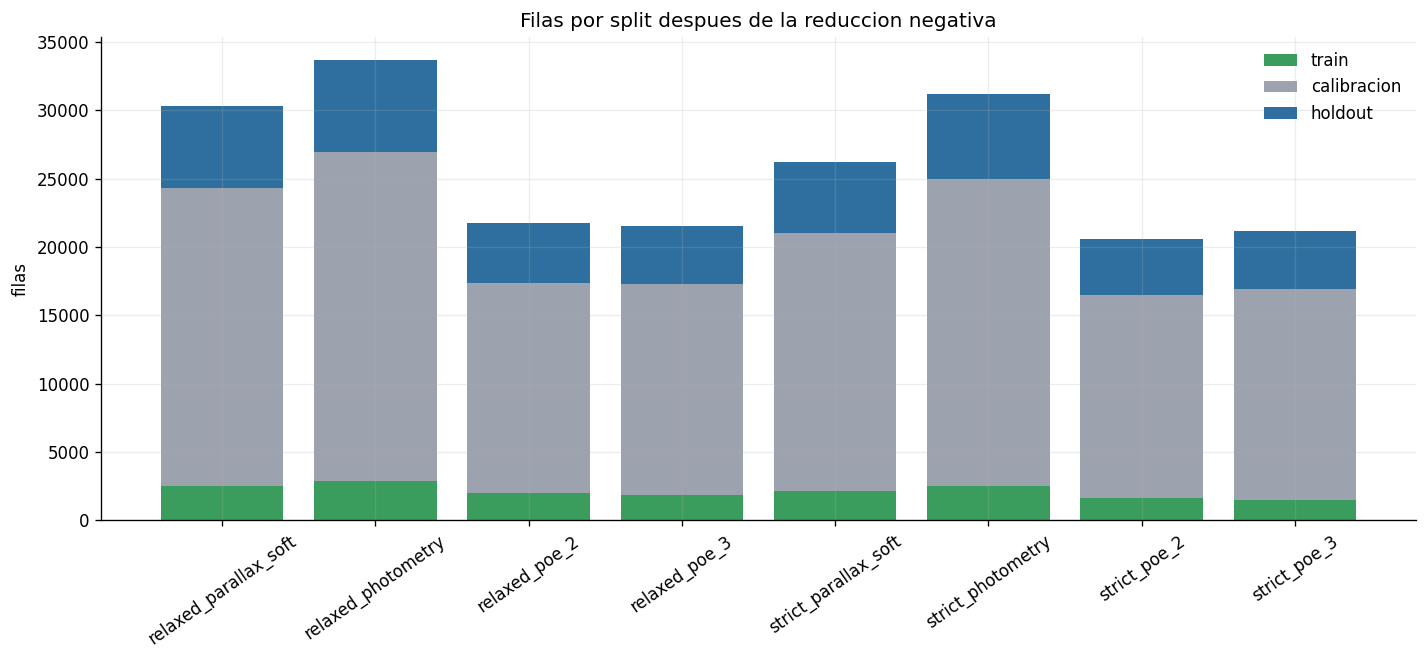

In [2]:
rows = []
for path in sorted(modeling_dir.glob("*_reduced.parquet")):
    variant = path.stem.replace("_reduced", "")
    df = pd.read_parquet(path, columns=["target", "modeling_split"])
    for split, group in df.groupby("modeling_split"):
        rows.append({
            "dataset_variant": variant,
            "split": split,
            "rows": len(group),
            "wr": int(group["target"].sum()),
            "non_wr": int((group["target"] == 0).sum()),
        })
dims = pd.DataFrame(rows)
display(dims.pivot_table(index="dataset_variant", columns="split", values=["rows", "wr", "non_wr"], aggfunc="sum").fillna(0).astype(int))

plot = dims.pivot(index="dataset_variant", columns="split", values="rows").fillna(0)
plot = plot[[c for c in ["train", "threshold_calibration", "holdout"] if c in plot.columns]]
fig, ax = plt.subplots(figsize=(12, 5.6))
colors = ["#3A9D5D", "#9CA3AF", "#2F6F9F"]
bottom = np.zeros(len(plot))
for col, color in zip(plot.columns, colors):
    label = "calibracion" if col == "threshold_calibration" else col
    ax.bar(plot.index, plot[col], bottom=bottom, color=color, label=label)
    bottom += plot[col].to_numpy()
ax.set_title("Filas por split despues de la reduccion negativa")
ax.set_ylabel("filas")
ax.tick_params(axis="x", rotation=35)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Reduccion negativa train-only


,dataset_variant,train_wr,train_negative_original,train_negative_reduced,train_neg_per_wr,threshold_calibration_negative,holdout_rows,holdout_wr,holdout_negative,holdout_wr_pct
0,strict_photometry,230,24774,2300,10.00,22474,6194,62,6132,1.001%
1,strict_parallax_soft,194,20796,1940,10.00,18856,5191,54,5137,1.040%
2,strict_poe_2,150,16324,1500,10.00,14824,4081,42,4039,1.029%
3,strict_poe_3,136,16820,1360,10.00,15460,4197,37,4160,0.882%
4,relaxed_photometry,262,26709,2620,10.00,24089,6703,69,6634,1.029%
5,relaxed_parallax_soft,225,24063,2250,10.00,21813,6045,59,5986,0.976%
6,relaxed_poe_2,181,17198,1810,10.00,15388,4337,46,4291,1.061%
7,relaxed_poe_3,167,17120,1670,10.00,15450,4265,41,4224,0.961%


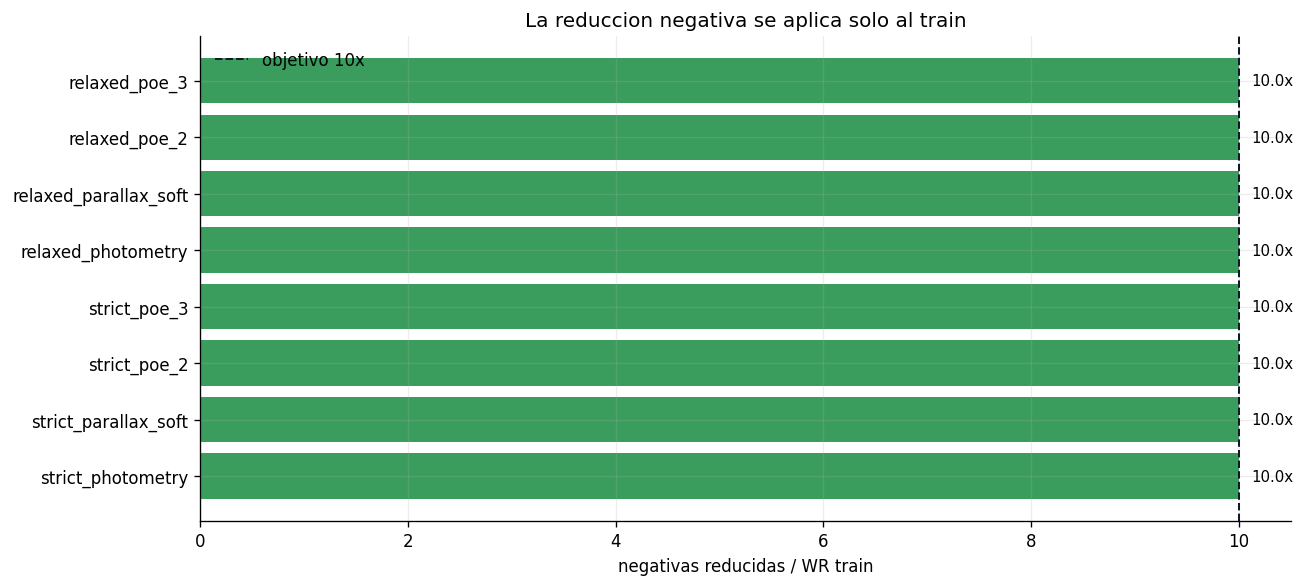

In [3]:
view = summary.copy()
view["train_neg_per_wr"] = view["train_negative_reduced"] / view["train_wr"].replace(0, np.nan)
view["holdout_wr_pct"] = view["holdout_wr"] / view["holdout_rows"].replace(0, np.nan)
display(view[[
    "dataset_variant", "train_wr", "train_negative_original", "train_negative_reduced",
    "train_neg_per_wr", "threshold_calibration_negative", "holdout_rows", "holdout_wr",
    "holdout_negative", "holdout_wr_pct"
]].style.format({"train_neg_per_wr": "{:.2f}", "holdout_wr_pct": "{:.3%}"}))

fig, ax = plt.subplots(figsize=(11, 5))
plot = view.sort_values("train_neg_per_wr")
ax.barh(plot["dataset_variant"], plot["train_neg_per_wr"], color="#3A9D5D")
ax.axvline(10, color="#111827", ls="--", lw=1.2, label="objetivo 10x")
for y, val in enumerate(plot["train_neg_per_wr"]):
    ax.text(val + 0.12, y, f"{val:.1f}x", va="center", fontsize=9)
ax.set_xlabel("negativas reducidas / WR train")
ax.set_title("La reduccion negativa se aplica solo al train")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Representatividad de colores


,dataset_variant,color,original_n,reduced_n,original_mean,reduced_mean,original_std,reduced_std,ks_statistic,wasserstein_distance
25,strict_poe_3,J_K,16820,1360,0.7010,0.7131,0.5146,0.5060,0.0362,0.0178
26,strict_poe_3,H_K,16820,1360,0.2323,0.2347,0.2034,0.1957,0.0276,0.0074
22,strict_poe_3,G_BP,16820,1360,-0.8011,-0.8309,0.6873,0.7046,0.0261,0.0309
21,strict_poe_3,BP_RP,16820,1360,1.5781,1.6223,1.0494,1.0729,0.0256,0.0450
24,strict_poe_3,J_H,16820,1360,0.4687,0.4784,0.3261,0.3241,0.0254,0.0117
23,strict_poe_3,G_RP,16820,1360,0.7770,0.7913,0.3736,0.3796,0.0252,0.0146
11,strict_parallax_soft,J_K,20796,1940,0.8510,0.8450,0.6203,0.5978,0.0252,0.0159
6,strict_photometry,W1_W2,24774,2300,0.1007,0.0992,0.2472,0.2539,0.0229,0.0083
3,strict_photometry,J_H,24774,2300,0.6536,0.6660,0.4291,0.4348,0.0227,0.0131
16,strict_poe_2,G_RP,16324,1500,0.7933,0.7834,0.3816,0.3788,0.0227,0.0114


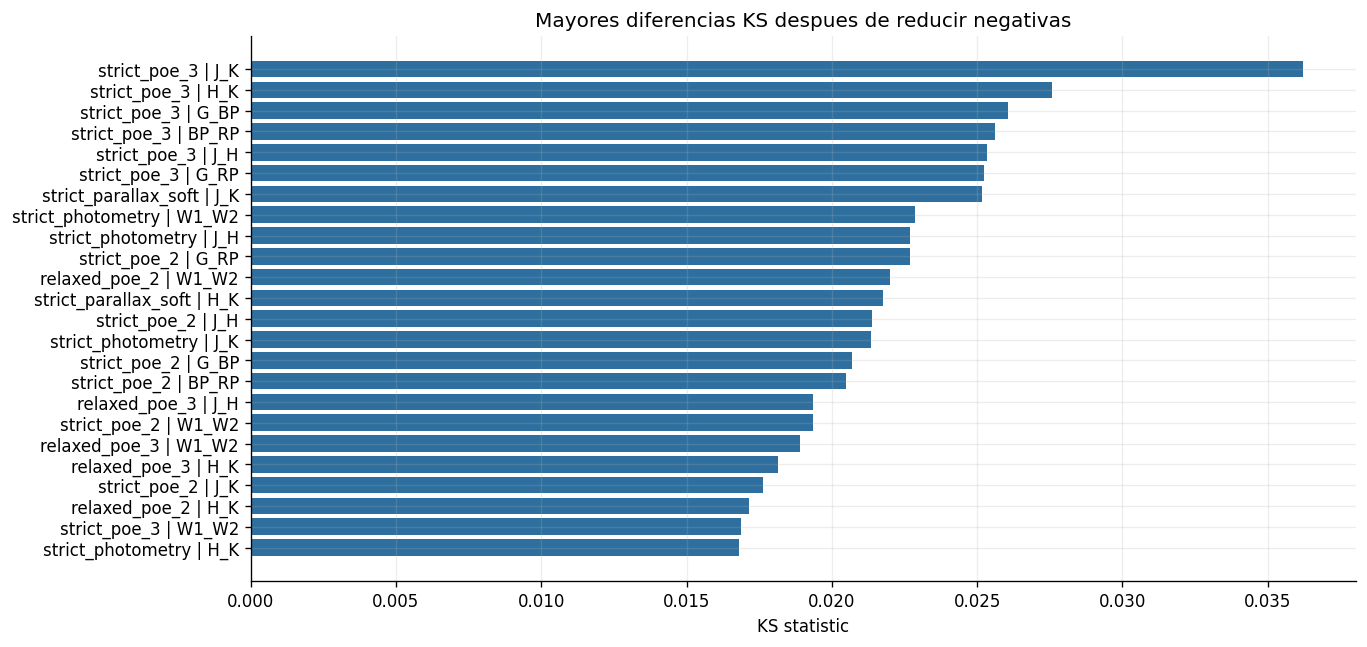

In [4]:
display(audit.sort_values("ks_statistic", ascending=False).head(24).style.format(precision=4))

fig, ax = plt.subplots(figsize=(11.5, 5.5))
plot = audit.sort_values("ks_statistic", ascending=False).head(24).iloc[::-1]
ax.barh(plot["dataset_variant"] + " | " + plot["color"], plot["ks_statistic"], color="#2F6F9F")
ax.set_title("Mayores diferencias KS despues de reducir negativas")
ax.set_xlabel("KS statistic")
plt.tight_layout()
plt.show()


## Auditoria de pools negativos


,dataset_variant,pool,color,n,mean,std,p05,p50,p95,ks_vs_all_negative,wasserstein_vs_all_negative
75,strict_poe_3,train_reduced_negative,J_K,1360,0.7131,0.5060,0.1980,0.5305,1.7801,0.0396,0.0198
78,strict_poe_3,train_reduced_negative,H_K,1360,0.2347,0.1957,0.0450,0.1780,0.6372,0.0310,0.0080
72,strict_poe_3,train_reduced_negative,J_H,1360,0.4784,0.3241,0.1269,0.3790,1.1522,0.0289,0.0135
66,strict_poe_3,train_reduced_negative,G_BP,1360,-0.8309,0.7046,-2.1897,-0.4765,-0.1575,0.0284,0.0356
63,strict_poe_3,train_reduced_negative,BP_RP,1360,1.6223,1.0729,0.4684,1.1418,3.5828,0.0283,0.0524
69,strict_poe_3,train_reduced_negative,G_RP,1360,0.7913,0.3796,0.3062,0.6668,1.4150,0.0281,0.0171
33,strict_parallax_soft,train_reduced_negative,J_K,1940,0.8450,0.5978,0.1970,0.6775,1.9610,0.0257,0.0157
36,strict_parallax_soft,train_reduced_negative,H_K,1940,0.2789,0.2300,0.0440,0.2330,0.7320,0.0229,0.0077
9,strict_photometry,train_reduced_negative,J_H,2300,0.6660,0.4348,0.1309,0.6140,1.3751,0.0228,0.0141
144,relaxed_poe_2,train_reduced_negative,W1_W2,1810,0.1169,0.2656,-0.1116,0.0010,0.6287,0.0226,0.0091


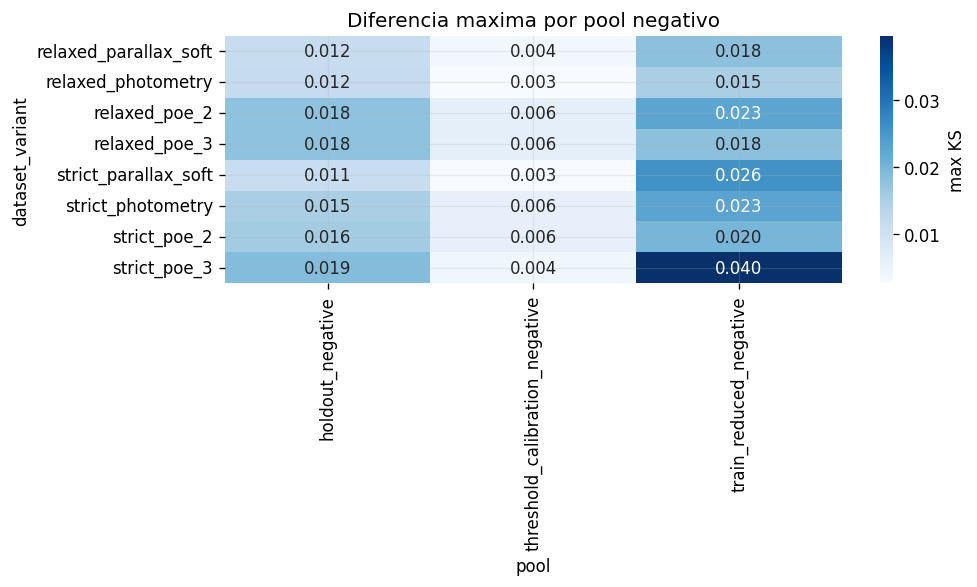

In [5]:
if pool_audit.empty:
    display(Markdown("No existe `negative_pool_audit.csv`."))
else:
    heat = pool_audit.pivot_table(index="dataset_variant", columns="pool", values="ks_vs_all_negative", aggfunc="max")
    display(pool_audit.sort_values("ks_vs_all_negative", ascending=False).head(25).style.format(precision=4))
    fig, ax = plt.subplots(figsize=(8.5, 5))
    if sns:
        sns.heatmap(heat, annot=True, fmt=".3f", cmap="Blues", ax=ax, cbar_kws={"label": "max KS"})
    else:
        im = ax.imshow(heat.fillna(0), cmap="Blues")
        ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(heat.index)), heat.index)
        plt.colorbar(im, ax=ax, label="max KS")
    ax.set_title("Diferencia maxima por pool negativo")
    plt.tight_layout()
    plt.show()


## Histogramas antes/despues


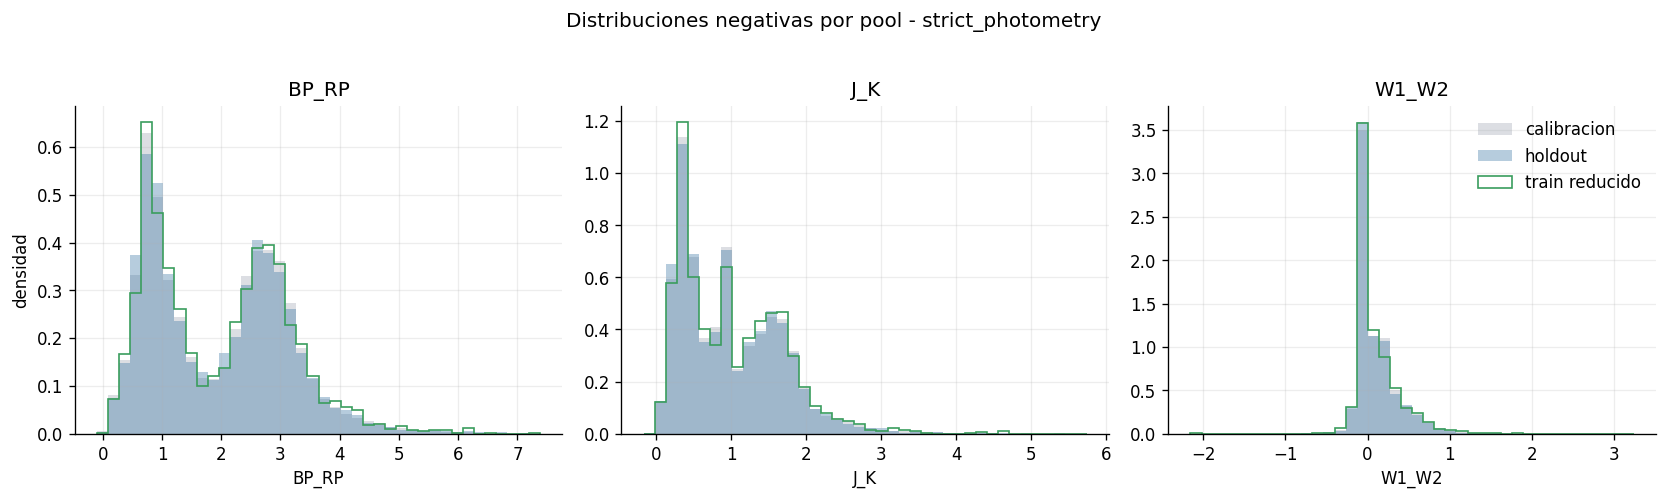

In [6]:
VARIANT = "strict_photometry"
COLORS = ["BP_RP", "J_K", "W1_W2"]
df = pd.read_parquet(modeling_dir / f"{VARIANT}_reduced.parquet")
neg = df[df["target"].eq(0)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, color in zip(axes, COLORS):
    parts = {
        "train reducido": neg[neg["modeling_split"].eq("train")][color].dropna(),
        "calibracion": neg[neg["modeling_split"].eq("threshold_calibration")][color].dropna(),
        "holdout": neg[neg["modeling_split"].eq("holdout")][color].dropna(),
    }
    bins = np.histogram_bin_edges(pd.concat(list(parts.values())), bins=40)
    ax.hist(parts["calibracion"], bins=bins, density=True, alpha=0.35, color="#9CA3AF", label="calibracion")
    ax.hist(parts["holdout"], bins=bins, density=True, alpha=0.35, color="#2F6F9F", label="holdout")
    ax.hist(parts["train reducido"], bins=bins, density=True, histtype="step", lw=2, color="#3A9D5D", label="train reducido")
    ax.set_title(color)
    ax.set_xlabel(color)
axes[0].set_ylabel("densidad")
axes[-1].legend(frameon=False)
fig.suptitle(f"Distribuciones negativas por pool - {VARIANT}", y=1.03)
plt.tight_layout()
plt.show()


## Color-color checks


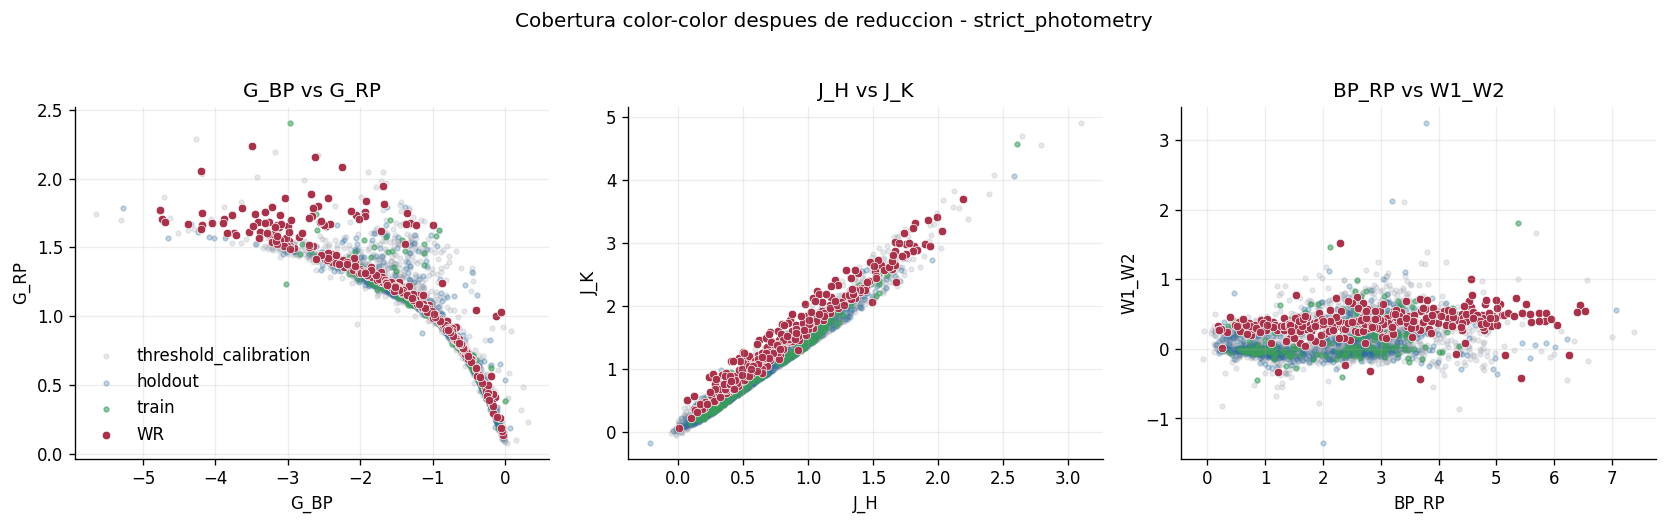

In [7]:
VARIANT = "strict_photometry"
df = pd.read_parquet(modeling_dir / f"{VARIANT}_reduced.parquet")
wr = df[df["target"].eq(1)]
neg = df[df["target"].eq(0)]
if len(neg) > 3500:
    neg = neg.sample(3500, random_state=42)
planes = [("G_BP", "G_RP"), ("J_H", "J_K"), ("BP_RP", "W1_W2")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (x, y) in zip(axes, planes):
    for split, color, alpha in [("threshold_calibration", "#9CA3AF", 0.22), ("holdout", "#2F6F9F", 0.28), ("train", "#3A9D5D", 0.55)]:
        part = neg[neg["modeling_split"].eq(split)]
        ax.scatter(part[x], part[y], s=8, alpha=alpha, color=color, label=split if (x, y) == planes[0] else None)
    ax.scatter(wr[x], wr[y], s=26, color=PALETTE["wr"], edgecolor="white", linewidth=0.4, label="WR" if (x, y) == planes[0] else None)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
axes[0].legend(frameon=False)
fig.suptitle(f"Cobertura color-color despues de reduccion - {VARIANT}", y=1.03)
plt.tight_layout()
plt.show()
